### STEP 1: Import Libraries

### What this code does:

### Loads the dataset
###  Shows dataset structure
### Finds missing values
### Cleans missing data using median and mode
### Removes duplicates
### Standardizes categorical text
### Removes invalid negative values
### Separates features (X) and target (y)
### Saves cleaned dataset as heart_cleaned.xlsx

In [8]:
# ==========================================
# HEART DISEASE DATA CLEANING
# ==========================================

# Import libraries
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD DATASET
# ==========================================

# Read Excel file
df = pd.read_excel("heart-2.xlsx")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())


# ==========================================
# 2. INSPECT DATASET
# ==========================================

# Dataset shape
print("\nDataset Shape:")
print(df.shape)

# Dataset information
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())


# ==========================================
# 3. CHECK MISSING VALUES
# ==========================================

# Count missing values
print("\nMissing Values:")
print(df.isnull().sum())


# ==========================================
# 4. HANDLE MISSING VALUES
# ==========================================

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fill missing numerical values using median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill missing categorical values using mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# ==========================================
# 5. CHECK DUPLICATES
# ==========================================

# Count duplicate rows
duplicates = df.duplicated().sum()

print("\nNumber of Duplicate Rows:", duplicates)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")


# ==========================================
# 6. STANDARDIZE CATEGORICAL DATA
# ==========================================

# Convert categorical columns to lowercase
# and remove extra spaces

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("\nCategorical Data Standardized")


# ==========================================
# 7. CHECK INVALID VALUES
# ==========================================

# Example:
# Remove impossible negative values

if 'trestbps' in df.columns:
    df = df[df['trestbps'] >= 0]

if 'chol' in df.columns:
    df = df[df['chol'] >= 0]

print("\nInvalid Values Removed")


# ==========================================
# 8. FEATURE AND TARGET SEPARATION
# ==========================================

# Target column
target_col = 'target'

# Features
X = df.drop(target_col, axis=1)

# Target variable
y = df[target_col]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)


# ==========================================
# 9. FINAL DATASET CHECK
# ==========================================

print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Cleaned Dataset:")
print(df.head())


# ==========================================
# 10. SAVE CLEANED DATASET
# ==========================================

df.to_excel("heart_cleaned.xlsx", index=False)

print("\nCleaned Dataset Saved Successfully")

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape:
(1025, 14)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non

C:\Users\Haier\AppData\Local\Temp\ipykernel_13528\3810254709.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Cleaned Dataset Saved Successfully


In [9]:
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve, precision_score, recall_score, f1_score

### The evaluation metrics used in the abovecode 
#### One is accuracy_score and the other one is Classification_report 
##### The Classification report internally computes:
##### Precision 
##### Recall
##### F1_Score
##### Support(number of samples)

### STEP 2: Load Dataset (Data Cleaning & Preparation)

In [11]:
df = pd.read_excel("heart-2.xlsx")

# Check duplicates
df = df.drop_duplicates()

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### Academic justification:

#### Standardization improves model stability and comparability.

### STEP 3: Exploratory Data Analysis (EDA)

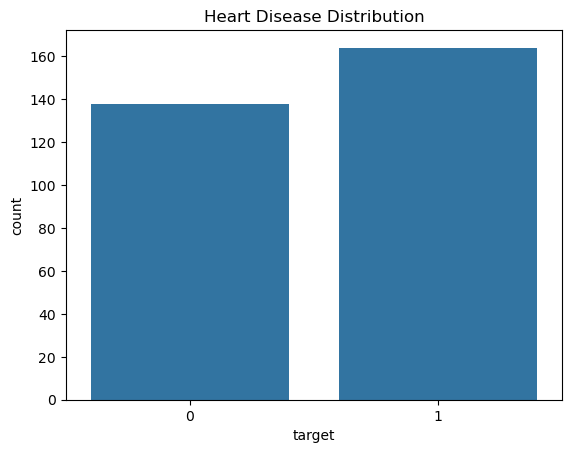

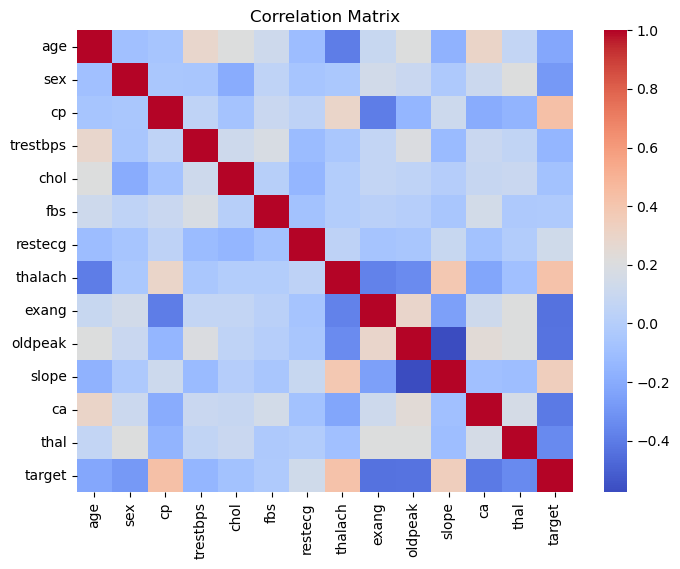

In [12]:
# Target distribution
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### I will use this in Results chapter to explain relationships.

### STEP 4: Train–Test Split

In [13]:
# Split data into training and testing sets (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)

### 🧠 STEP 5: Predictive Modeling
####  Logistic Regression (Interpretable Baseline)

In [14]:
# Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
# Train model
log_model.fit(X_train, y_train)

# Predictions
log_pred = log_model.predict(X_test)

# Confusion Matrix
cm_log = confusion_matrix(y_test, log_pred)

log_prob = log_model.predict_proba(X_test)[:,1]

# Performance Metrics
accuracy_log = accuracy_score(y_test, log_pred)
precision_log = precision_score(y_test, log_pred)
recall_log = recall_score(y_test, log_pred)
f1_log = f1_score(y_test, log_pred)

# Print results
print("Logistic Regression Results")
print("Confusion Matrix:\n", cm_log)
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-score:", f1_log)

Logistic Regression Results
Confusion Matrix:
 [[21 11]
 [ 3 26]]
Accuracy: 0.7704918032786885
Precision: 0.7027027027027027
Recall: 0.896551724137931
F1-score: 0.7878787878787878


#### Decision Tree

In [15]:
# Initialize Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)

# Performance Metrics
accuracy_dt = accuracy_score(y_test, dt_pred)
precision_dt = precision_score(y_test, dt_pred)
recall_dt = recall_score(y_test, dt_pred)
f1_dt = f1_score(y_test, dt_pred)

# Print results
print("\nDecision Tree Results")
print("Confusion Matrix:\n", cm_dt)
print("Accuracy:", accuracy_dt)
print("Precision:", precision_dt)
print("Recall:", recall_dt)
print("F1-score:", f1_dt)


Decision Tree Results
Confusion Matrix:
 [[25  7]
 [ 9 20]]
Accuracy: 0.7377049180327869
Precision: 0.7407407407407407
Recall: 0.6896551724137931
F1-score: 0.7142857142857143


#### Random Forest

In [16]:
# Initialize Random Forest model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)

rf_prob = rf_model.predict_proba(X_test)[:,1]

# Performance Metrics
accuracy_rf = accuracy_score(y_test, rf_pred)
precision_rf = precision_score(y_test, rf_pred)
recall_rf = recall_score(y_test, rf_pred)
f1_rf = f1_score(y_test, rf_pred)

# Print results
print("\nRandom Forest Results")
print("Confusion Matrix:\n", cm_rf)
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)


Random Forest Results
Confusion Matrix:
 [[26  6]
 [ 3 26]]
Accuracy: 0.8524590163934426
Precision: 0.8125
Recall: 0.896551724137931
F1-score: 0.8524590163934426


### STEP 6: Model Evaluation

In [17]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.7704918032786885
Decision Tree Accuracy: 0.7377049180327869
Random Forest Accuracy: 0.8524590163934426


#### I will compare, not chase accuracy.

### STEP 7: Feature Importance (CORE CONTRIBUTION)
#### Logistic Regression Coefficients

In [18]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance

,Feature,Coefficient
2,cp,1.008024
6,restecg,0.490567
7,thalach,0.475461
10,slope,0.343483
5,fbs,-0.046123
0,age,-0.064869
4,chol,-0.087097
8,exang,-0.275337
12,thal,-0.390354
3,trestbps,-0.564789


#### Random Forest Importance

In [21]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_importance

,Feature,Importance
7,thalach,0.130246
2,cp,0.126030
9,oldpeak,0.118301
12,thal,0.113892
11,ca,0.096178
0,age,0.090891
3,trestbps,0.074502
4,chol,0.072694
10,slope,0.052614
8,exang,0.047001


##### This section(the above) differentiates my research from Kaggle.

###  STEP 8: Risk Stratification Framework

In [22]:
risk_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_Probability': rf_prob
})

risk_df['Risk_Level'] = pd.cut(
    risk_df['Predicted_Probability'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

risk_df.head()

,Actual,Predicted_Probability,Risk_Level
245,1,0.995,High Risk
349,0,0.455,Medium Risk
135,0,0.140,Low Risk
389,1,0.455,Medium Risk
66,1,0.860,High Risk


##### THIS IS My CORE BUSINESS ANALYTICS VALUE

###  STEP 9: Business Analytics Interpretation
##### Interpretation:

##### High-risk patients show strong association with:

###### Chest pain type

###### Maximum heart rate

###### Exercise-induced angina

###### Medium-risk group requires lifestyle monitoring

###### Low-risk group suitable for preventive guidance

### STEP 10: Managerial & Policy Recommendations
#### Managerial:

###### Prioritize screening for high-risk patients

###### Allocate cardiology resources efficiently

###### Reduce long-term treatment costs

#### Policy:

###### Preventive healthcare programs

###### Data-driven screening policies

###### Public health risk segmentation

## The summary of applied machine learning models

#### “Each machine learning model was trained using an 80–20 train–test split. Logistic Regression required feature standardization due to its sensitivity to scale, whereas tree-based models were trained on unscaled data. Model performance was evaluated using confusion matrices and classification metrics including accuracy, precision, recall, and F1-score.”